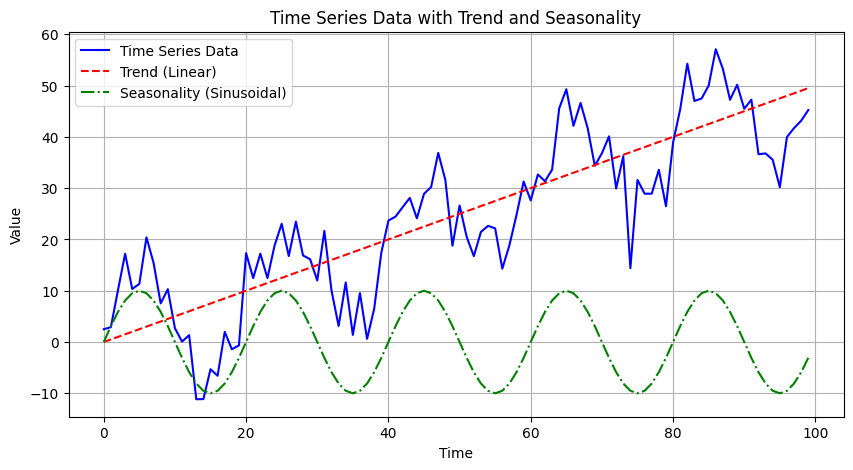

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시계열 데이터 생성 (추세 + 계절성 + 노이즈)
np.random.seed(42)
time = np.arange(0, 100)
trend = 0.5 * time  # 선형 추세
seasonality = 10 * np.sin(2 * np.pi * time / 20)  # 계절성 (주기 20)
noise = np.random.normal(0, 5, size=len(time))  # 랜덤 노이즈

# 전체 시계열 데이터
data = trend + seasonality + noise

# 데이터프레임으로 구성
df = pd.DataFrame({'Time': time, 'Value': data})

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(df['Time'], df['Value'], label='Time Series Data', color='blue')
plt.plot(df['Time'], trend, label='Trend (Linear)', color='red', linestyle='--')
plt.plot(df['Time'], seasonality, label='Seasonality (Sinusoidal)', color='green', linestyle='-.')
plt.title('Time Series Data with Trend and Seasonality')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


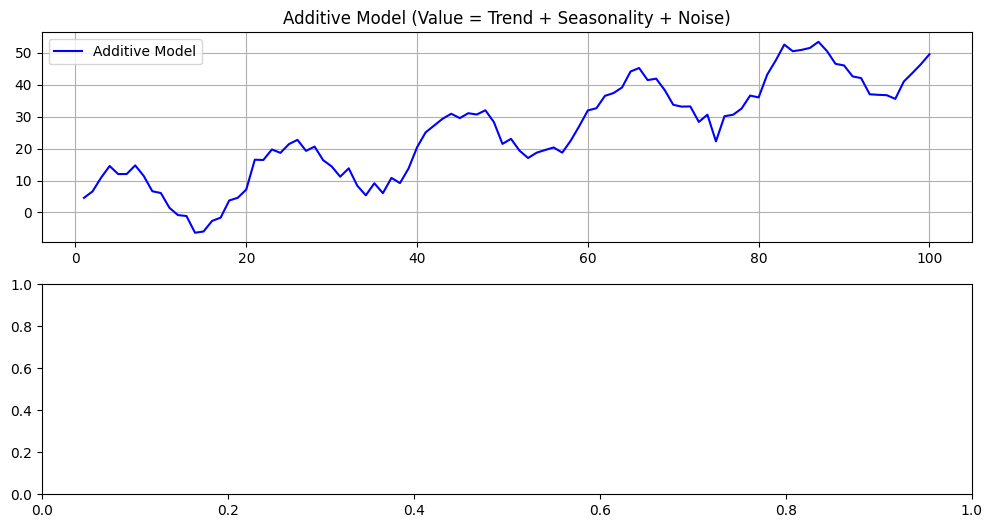

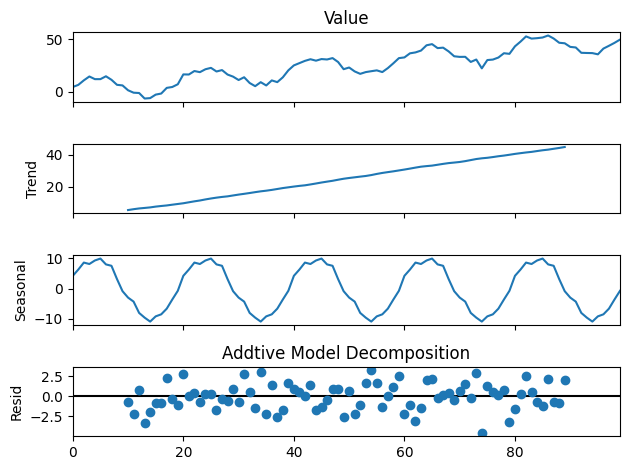

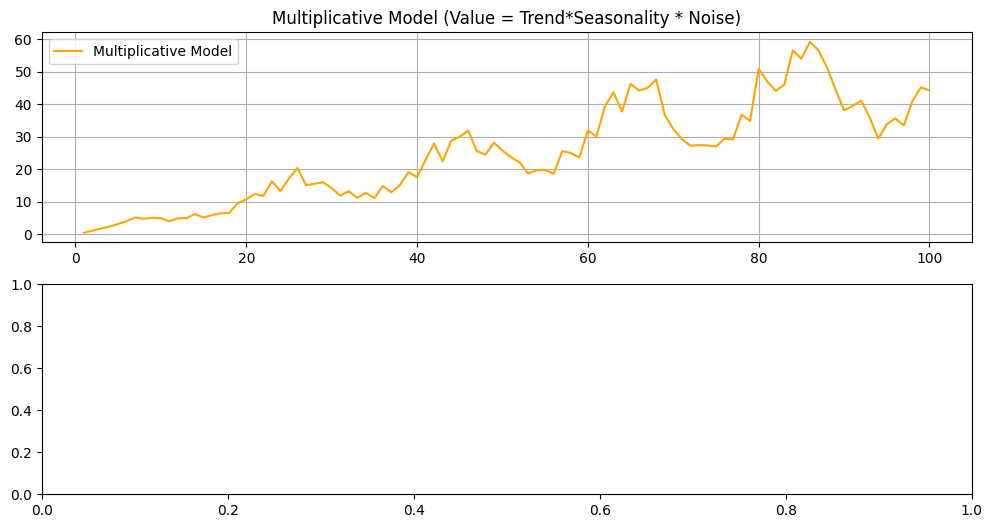

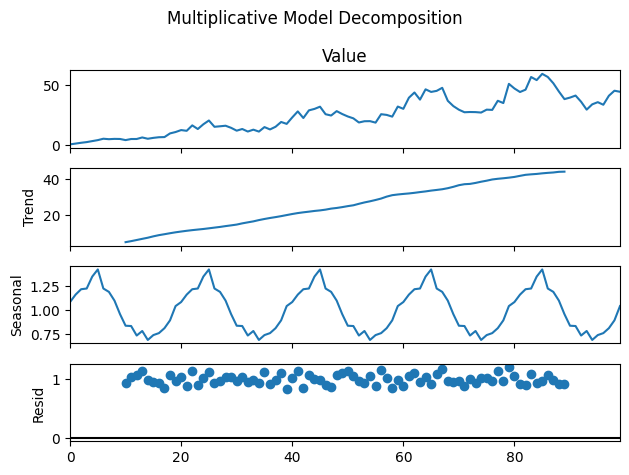

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 데이터 생성 (추세 + 계절성 + 노이즈)
np.random.seed(42)
time = np.arange(1, 101)
trend = 0.5 * time  # 선형 추세

# 가법(+) 모델
seasonality_add = 10 * np.sin(2 * np.pi * time / 20)
data_additive = trend + seasonality_add + np.random.normal(0, 2, len(time))

# 승법(*) 모델
seasonality_mult = 1 + 0.3 * np.sin(2 * np.pi * time / 20)
data_multiplicative = trend * seasonality_mult * (1 + np.random.normal(0, 0.1, len(time)))

# 데이터프레임 생성
df_add = pd.DataFrame({'Time': time, 'Value': data_additive})
df_mult = pd.DataFrame({'Time': time, 'Value': data_multiplicative})

# 가법 모델 분해
result_add = seasonal_decompose(df_add['Value'], model='additive', period=20)
result_mult = seasonal_decompose(df_mult['Value'], model='multiplicative', period=20)
# 시각화(가법 모델)
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(df_add['Time'], df_add['Value'], label='Additive Model', color = 'blue')
plt.title('Additive Model (Value = Trend + Seasonality + Noise)')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
result_add.plot()
plt.title('Addtive Model Decomposition')
plt.tight_layout()
plt.show()

# 시각화 (승법모델)
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(df_mult['Time'], df_mult['Value'], label='Multiplicative Model', color = 'orange')
plt.title('Multiplicative Model (Value = Trend*Seasonality * Noise)')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
result_mult.plot()
plt.suptitle('Multiplicative Model Decomposition')
plt.tight_layout()
plt.show()

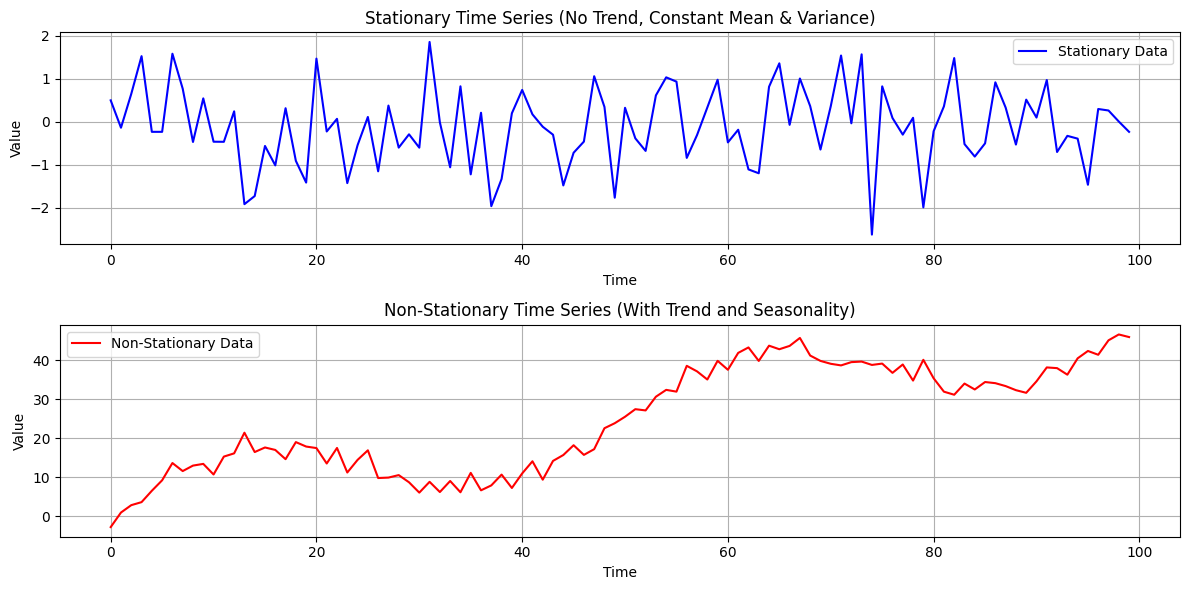

In [25]:
# 랜덤 시드 설정
np.random.seed(42)

# 정상성 데이터 생성(평균과 분산이 일정)
time = np.arange(100)
stationaly_data = np.random.normal(loc=0, scale = 1, size = 100)

# 비정상성 데이터 생성 (추세가 존재)
trend = 0.5*time
seasonality = 10*np.sin(2*np.pi * time/50)
non_seasonary_data = trend + seasonality + np.random.normal(loc=0, scale=2, size = 100)

# 데이터 프레임 생성
df = pd.DataFrame({
    'Time' : time,
    'Stationary' : stationaly_data,
    'Non_Stationary':non_seasonary_data
})

# 정상성과 비정상성 시각적 비교
plt.figure(figsize = (12,6))

plt.subplot(2,1,1)
plt.plot(df['Time'], df['Stationary'], label='Stationary Data', color='blue')
plt.title('Stationary Time Series (No Trend, Constant Mean & Variance)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.plot(df['Time'], df['Non_Stationary'], label='Non-Stationary Data', color = 'red')
plt.title('Non-Stationary Time Series (With Trend and Seasonality)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Original Non-Stationary Data Test:
ADF Test:Original Data
ADF Stastic: -0.5061268591997191
p-value: 0.8908153252383204
The series is non-stationary (Fail to reject H0
--------------------------------------------------
KPSS Test: Original Data
KPSS Statistic: 1.4618081359437394
p-value: 0.01
The series is non-stationary (Reject H0)
--------------------------------------------------
First Differenced Data Tests:
ADF Test:First Differenced Data
ADF Stastic: -4.718519089519554
p-value: 7.766408096422332e-05
The series is stationary (Reject H0
--------------------------------------------------
KPSS Test: First Differenced Data
KPSS Statistic: 0.29104598331888853
p-value: 0.1
the series is stationary (Fail to reject H0)
--------------------------------------------------
Second Differenced Data Tests:
ADF Test:second Differenced Data
ADF Stastic: -5.747441228535306
p-value: 6.075192843691364e-07
The series is stationary (Reject H0
--------------------------------------------------
KPSS Test: 

C:\Users\ghfjg\AppData\Local\Temp\ipykernel_24896\1119494638.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
C:\Users\ghfjg\AppData\Local\Temp\ipykernel_24896\1119494638.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
C:\Users\ghfjg\AppData\Local\Temp\ipykernel_24896\1119494638.py:33: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')


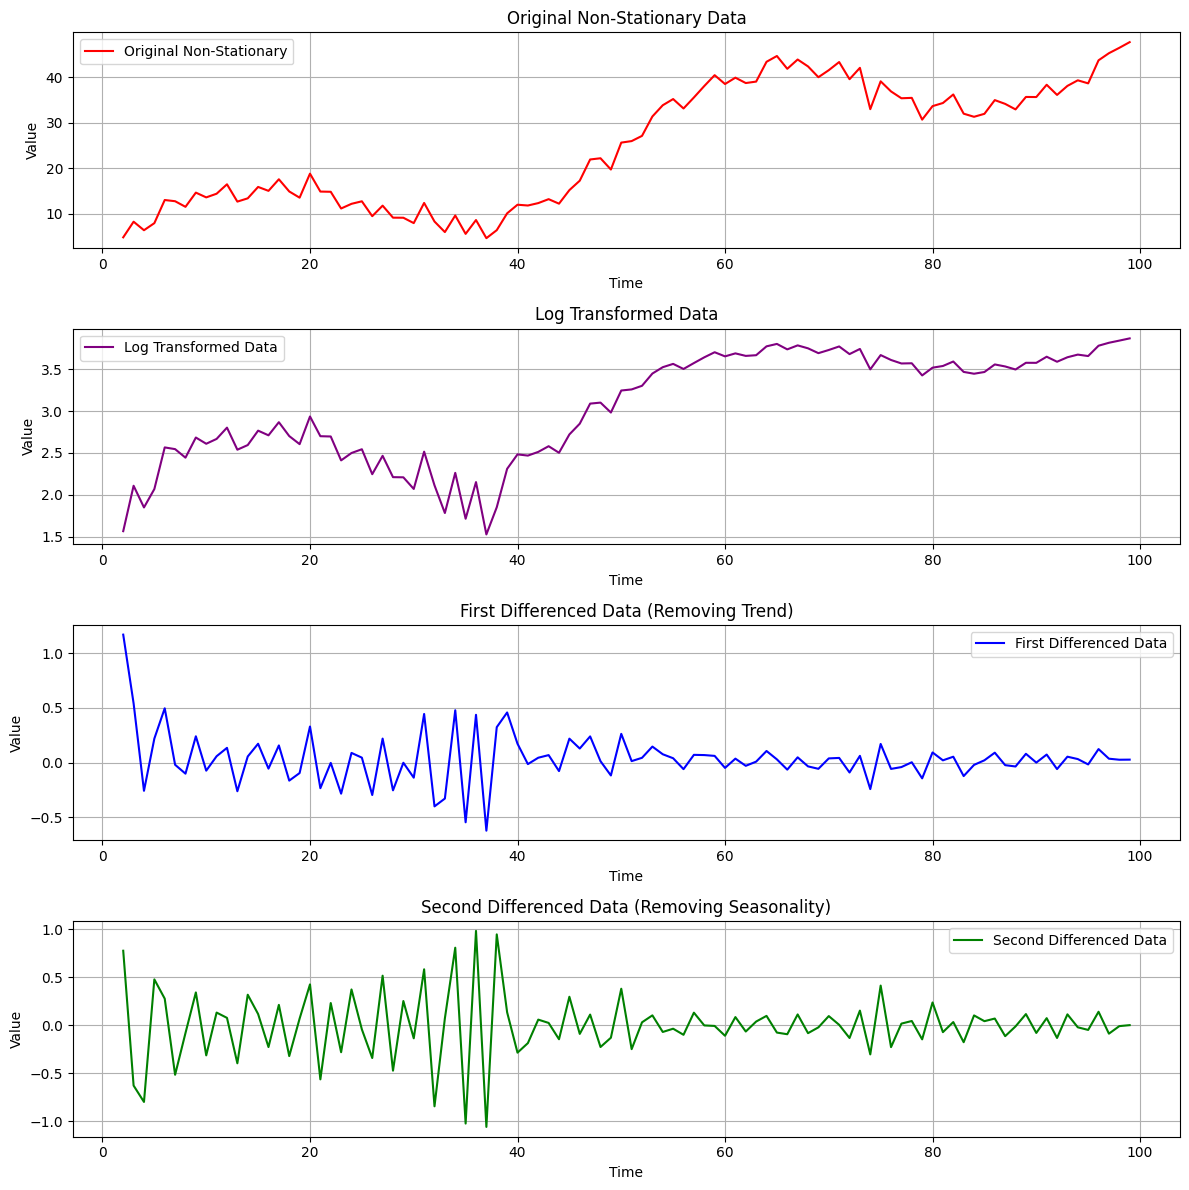

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# 데이터 생성(비정상적 데이터)
np.random.seed(42)
time = np.arange(100)
trend = 0.5*time #선형 추세
seasonality = 10*np.sin(2*np.pi*time/50)
non_stationary_data = trend + seasonality + np.random.normal(loc=0, scale=2, size=100)

# 데이터 프레임 생성
df = pd.DataFrame({
    'Time' : time, 
    'Non_Stationary':non_stationary_data
})

# ADF 테스트 함수
def adf_test(series, title):
    result = adfuller(series)
    print(f'ADF Test:{title}')
    print('ADF Stastic:',result[0])
    print('p-value:', result[1])
    if result[1]<0.05:
        print("The series is stationary (Reject H0")
    else:
        print("The series is non-stationary (Fail to reject H0")
    print("-"*50)

# KPSS 테스트 함수
def kpss_test(series, title):
    result = kpss(series, regression='c', nlags='auto')
    print(f"KPSS Test: {title}")
    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])
    if result[1]<0.05:
        print("The series is non-stationary (Reject H0)")
    else:
        print("the series is stationary (Fail to reject H0)")
    print("-"*50)

# 원본 데이터 정상성 검정 
print("Original Non-Stationary Data Test:")
adf_test(df['Non_Stationary'],"Original Data")
kpss_test(df['Non_Stationary'], "Original Data")

# 로그 변환 적용 (분산 안정화)
df['Log_Transformed'] = np.log(df['Non_Stationary'] - df['Non_Stationary'].min()+1)

# 1차 차분 적용
df['First_Differenced'] = df['Log_Transformed'].diff()

# 2차 차분 적용
df['Second_Differenced'] = df['First_Differenced'].diff()

# NaN 값 제거
df.dropna(inplace=True)

# 1차 및 2차 차분 후 정상성 검정
print("First Differenced Data Tests:")
adf_test(df['First_Differenced'], "First Differenced Data")
kpss_test(df['First_Differenced'], "First Differenced Data")

print("Second Differenced Data Tests:")
adf_test(df['Second_Differenced'], "second Differenced Data")
kpss_test(df['Second_Differenced'], "Second Differenced Data")

# 시각화
plt.figure(figsize=(12,12))

# 원본 데이터 시각화
plt.subplot(4,1,1)
plt.plot(df['Time'], df['Non_Stationary'], label="Original Non-Stationary", color='red')
plt.title('Original Non-Stationary Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

# 로그 변환 데이터 시각화
plt.subplot(4,1,2)
plt.plot(df['Time'], df['Log_Transformed'], label='Log Transformed Data', color='purple')
plt.title('Log Transformed Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

# 1차 차분 시각화
plt.subplot(4,1,3)
plt.plot(df['Time'], df['First_Differenced'], label='First Differenced Data', color='blue')
plt.title('First Differenced Data (Removing Trend)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

# 2차 차분 시각화
plt.subplot(4,1,4)
plt.plot(df['Time'], df['Second_Differenced'], label='Second Differenced Data', color = 'green')
plt.title('Second Differenced Data (Removing Seasonality)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()